<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>



 <hr style="height:5px"> 

    
<h2>Métodos de maximização das margens</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> e <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>  

 <hr style="height:2px"> 


## Introdução

Neste notebook, iremos explorar o método de **máquinas de vetores de suporte (SVM)** [1, 2] aplicando-o em exemplos com dois atributos e também utilizando a base de dados [Seeds](https://archive.ics.uci.edu/ml/datasets/seeds) [3]. As SVMs são amplamente utilizadas para tarefas de classificação, particularmente quando se deseja maximizar a margem entre as classes, resultando em um classificador robusto que busca a fronteira de decisão que separa as classes de forma ótima. Os experimentos apresentados foram desenvolvidos para demonstrar o funcionamento prático desse método, ilustrando como ele ajusta a fronteira de decisão e lida com dados de diferentes complexidades.

Este *notebook* se refere ao Capítulo **8 (Métodos de maximização de margens)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.5.3 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.24.3 ou superior): manipulação de dados em formato de vetores e matrizes
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 1.3.0 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial;
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`.

---

## Criando a primeira base de dados e visualizando suas amostras

Primeiro, iremos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-
import numpy as np #importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd #importa a biblioteca usada para trabalhar com dataframes

import sklearn as skl
from sklearn import datasets
from sklearn import preprocessing
from sklearn import metrics
from sklearn import svm

# biblioteca para geração de gráficos
import matplotlib.pyplot as plt

Iremos criar uma base de dados onde as amostras são separáveis linearmente. Para isso, iremos usar a classe *make_classification* da biblioteca *sklearn*. 

In [2]:
# Gerar dados de classificação
X, Y = skl.datasets.make_classification(n_samples=500, n_features=2, n_classes=2, n_informative=2, 
                                        n_redundant=0, n_clusters_per_class=1, class_sep = 2.3,  
                                        flip_y = 0.0, random_state=10)

# Imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# Imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

'X:'

array([[ 2.57155249, -3.39646407],
       [ 1.97644376, -1.5458409 ],
       [ 4.52009067, -5.57131377],
       [-0.74742755, -1.50460319],
       [-4.20023176, -1.78002802]])

Y: [0 0 0 1 1]


Agora, vamos criar uma função para plotar os dados.

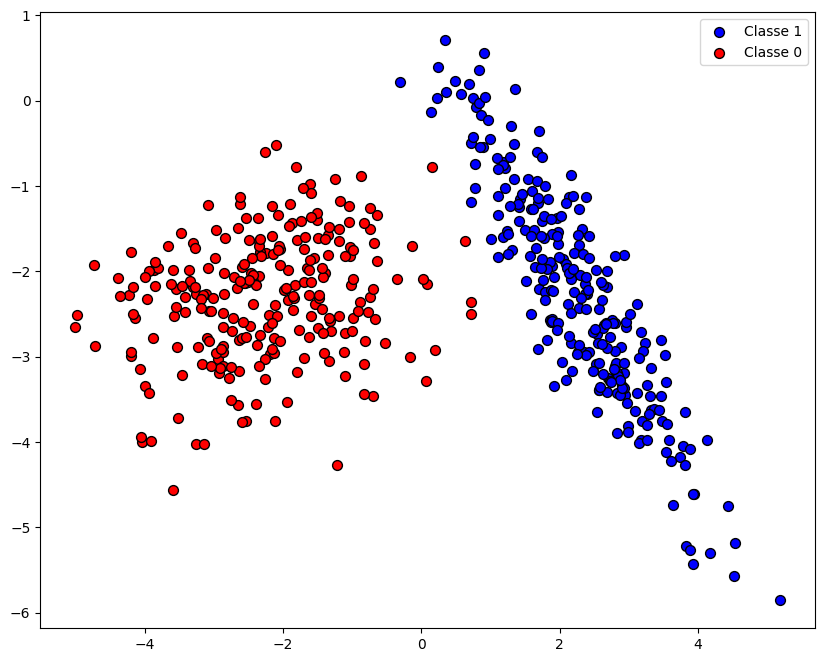

In [3]:
#função para plotar os dados
def visualizarDados(X,Y):
    """
    Função usada para plotar os dados
    """
    
    #define o tamanho da figura 
    plt.figure(figsize=(10,8))
    
    #plota os dados da classe 0
    plt.scatter( X[Y==0,0], X[Y==0,1], label='Classe 1', color='blue', s=50, edgecolors='k') 
    
    #plota os dados da classe 1
    plt.scatter( X[Y==1,0], X[Y==1,1], label='Classe 0', color='red', s=50, edgecolors='k') 
        
    #plota a legenda
    plt.legend()
    
#chama a função que plota os dados   
visualizarDados(X,Y)
plt.show()

## Treinando o SVM com kernel linear

Usando o código a seguir, iremos treinar um classificador SVM com kernel linear. Para isso, iremos empregar o método [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) da biblioteca **scikit-learn**.

Neste primeiro exemplo, vamos usar o kernel linear com valor de custo igual a 1.0. Na biblioteca *scikit learn*, o custo do SVM é um parâmetro que deve ter valor positivo e que é inverso à força de regularização. Quanto menor o valor desse parâmetro, maior é a regularização.

In [4]:
# inicia o classificador 
model = skl.svm.SVC(C=1.0, kernel='linear', random_state=10)

# treina o classificador com os dados de treinameto
model.fit(X, Y) 
 
print(model)

SVC(kernel='linear', random_state=10)


Agora, vamos visualizar o limite de decisão gerado pelo SVM.

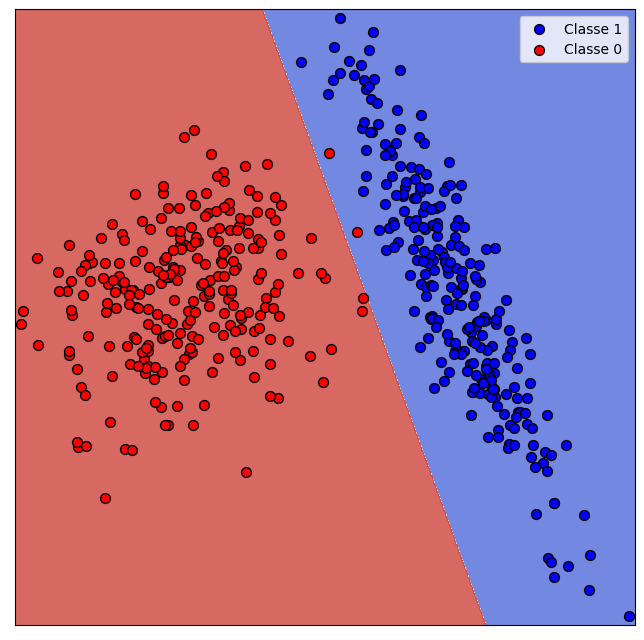

In [5]:
def plota_limite_decisao(model, X, Y, ax, title = ""):
    """
    Plota o limite de decisão
    """
   
    x = X[:, 0]
    y = X[:, 1]
    
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array(Z)
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    ax.set_xlim(x.min()-0.1, x.max()+0.1)
    ax.set_ylim(y.min()-0.1, y.max()+0.1)
    ax.set_xticks(())
    ax.set_yticks(())

    #plota os dados da classe 0
    plt.scatter( X[Y==0,0], X[Y==0,1], label='Classe 1', color='blue', s=50, edgecolors='k') 
    
    #plota os dados da classe 1
    plt.scatter( X[Y==1,0], X[Y==1,1], label='Classe 0', color='red', s=50, edgecolors='k') 
    
    # insere o título
    plt.title(title)

    #insere a legenda
    plt.legend()


# define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# plota o limite de decisão
plota_limite_decisao(model, X, Y, ax)
plt.show()

O gráfico acima apresenta o limite de decisão criado pelo modelo com custo igual a 1. Veja que com esse valor do parâmetro C, o modelo errou a predição de dois dados. 


Agora, vamos gerar outro modelo, mas usando custo igual a 100.

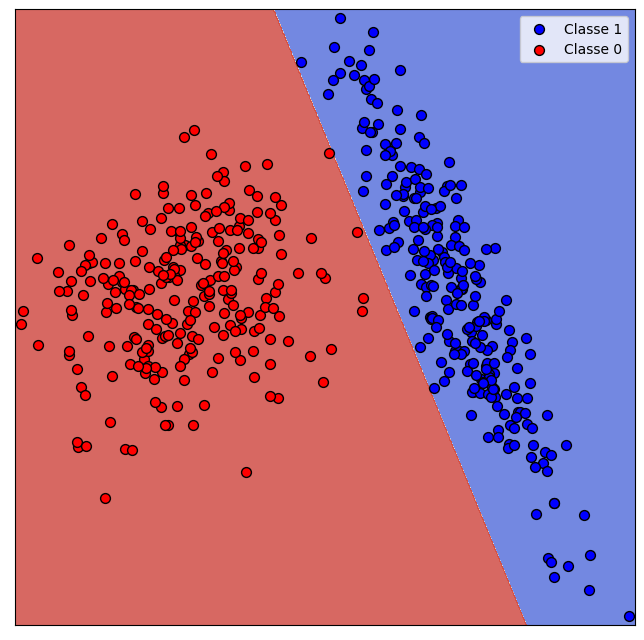

In [6]:
# inicia o classificador 
model = skl.svm.SVC(C=100.0, kernel='linear', random_state=10)

# treina o classificador com os dados de treinameto
model.fit(X, Y) 

# define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# plota o limite de decisão
plota_limite_decisao(model, X, Y, ax)
plt.show()

Conforme pode ser observado nos exemplos acima, quando usamos valores altos para o parâmetro de custo, o SVM tenta classificar todos os exemplos de treinameto corretamente.

Antes de ir para a próxima etapa, você pode testar outros valores de custo para o SVM e verificar como isso afeta o limite de decisão. 

## Treinando o SVM com função de kernel radial

Antes de implementar o SVM com função de kernel radial, iremos criar uma base de dados com amostras que não são linearmente separáveis.

'X:'

array([[ 0.0998033 ,  0.20842904],
       [-0.08791889,  0.02773161],
       [ 0.35093427,  0.0637235 ],
       [-0.41265949,  0.74423048],
       [-0.21400552, -0.36617041]])

Y: [1 1 1 0 1]


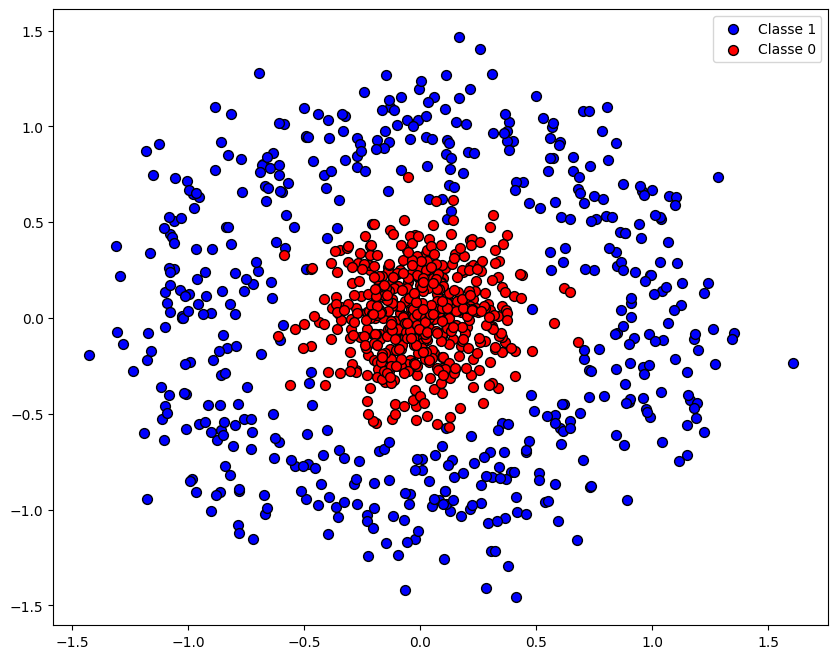

In [7]:
# Gera uma base de dados com dois círculos
X2, Y2 = skl.datasets.make_circles(n_samples=1000, noise=0.2, 
                                   factor=0.1, random_state = 10)

# imprime as 5 primeiras linhas da matriz X
display('X:', X2[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y2[0:5])

# plota os dados de treinamento
visualizarDados(X2,Y2)
plt.show()

Agora, vamos treinar o SVM com as amostras dessa segunda base de dados. Dessa vez, vamos usar o kernel radial. Iremos testar o parâmetro gamma e o custo com dois valores, sendo um grande e um pequeno. 

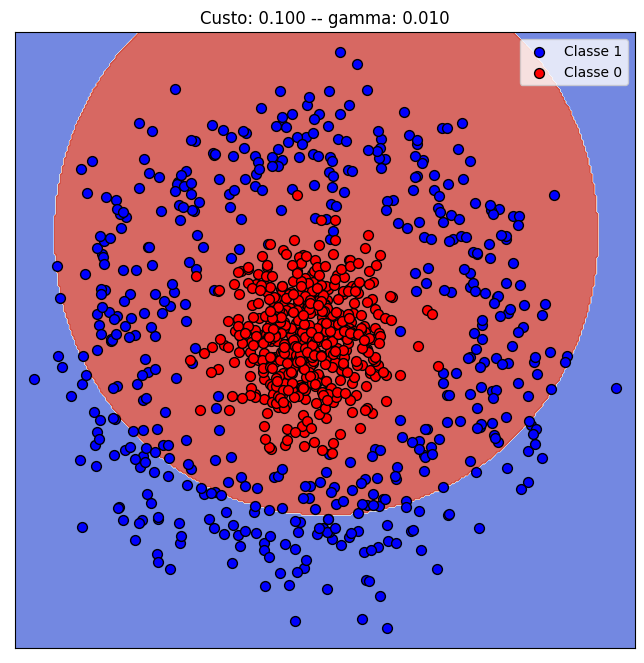

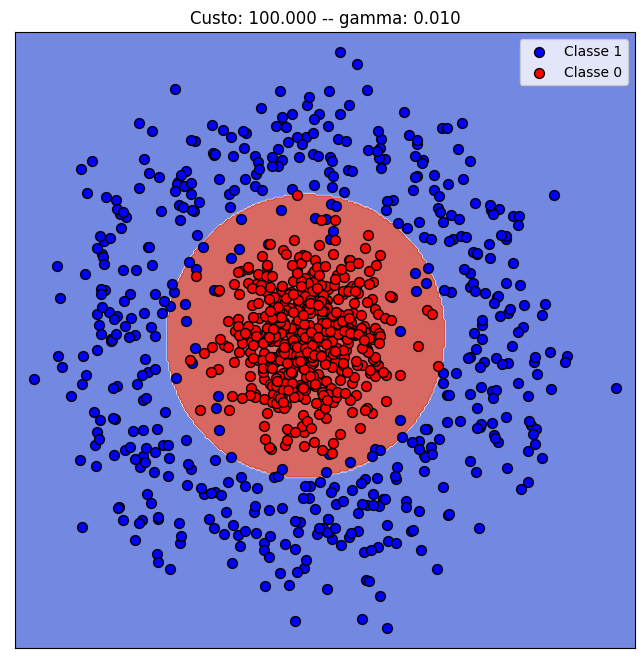

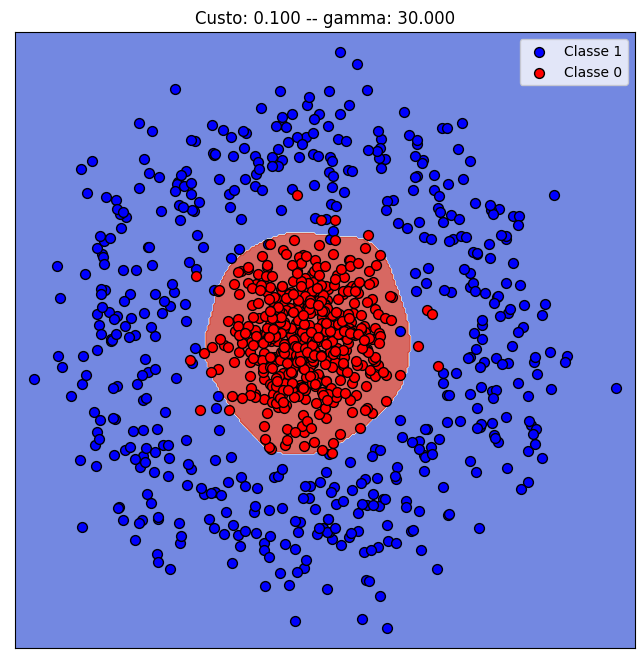

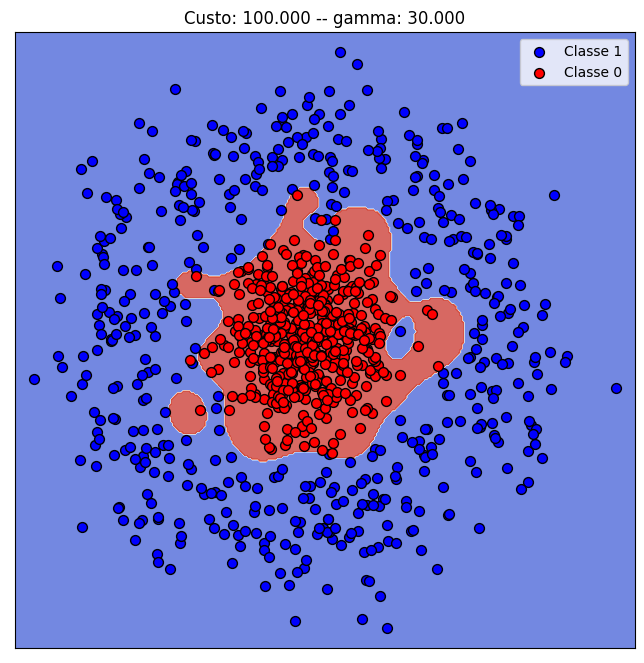

In [8]:
custo = [0.1, 100]
gamma = [0.01, 30]

# vamos treinar um método para cada valor de parâmetro
for gVal in gamma:
    for cVal in custo:
        
        # inicia o classificador 
        model = skl.svm.SVC(C=cVal, gamma=gVal, kernel='rbf', random_state=10)

        # treina o classificador com os dados de treinameto
        model.fit(X2, Y2) 

        # define o tamanho da figura
        fig, ax = plt.subplots(figsize=(8, 8)) 

        # Plota o limite de decisão
        title = "Custo: %1.3f -- gamma: %1.3f" %(cVal, gVal)
        plota_limite_decisao(model, X2, Y2, ax, title = title)
        plt.show()

Os limites de decisão mostrados pelos gráficos acima mostram que o SVM é bastante sensível à escolha dos parâmetros.

## Experimentos com a base de dados *Seeds*

Nesta parte do notebook, faremos experimentos com a base de dados *Seeds* [3]. Ela contém três variedades de trigo: Kama, Rosa e Canadense. Essas três variedades são representadas pelos seguintes atributos: área, perímetro, compacidade, comprimento do grão, largura do grão, coeficiente de assimetria e comprimento do sulco do grão. 

Primeiro, vamos carregar e visualizar algumas amostras da base de dados.

In [28]:
#importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv( 'datasets/seeds_dataset.txt', sep='\s+', header=None, index_col=None) 

display(df_dataset.head(n=6))

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1


Para facilitar a visualização, vamos nomear as colunas da base de dados com os nomes dos atributos. Depois, vamos substituir o valor das classes pelo nome da variedade de trigo que ela representa: 1 (Kama), 2 (Rosa), 3 (Canadense).

In [10]:
df_dataset.columns = ['area','perimetro','compacidade','compr.Grao','larg.Grao','coef.Assimetria', 'Compr.SulcoGrao', 'classe']

# converte as classes para string
df_dataset['classe'] = df_dataset['classe'].astype(str)

# troca o valor das classe pelo nome da variedade de trigo que ela representa
df_dataset["classe"] = df_dataset["classe"].replace({'1': 'Kama', '2': 'Rosa', '3': 'Canadense'})

# imprime o dataframe. 
display(df_dataset.head(6))

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,Kama


Vamos analisar as principais estatísticas sobre os atributos da base de dados.

In [11]:
# apresenta as principais estatísticas sobre a base de dados
df_detalhes = df_dataset.describe()

display(df_detalhes)

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


Vamos guardar os dados dentro de uma matriz e as classes dentro de um vetor.

In [12]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X3 = df_dataset.iloc[:, 0:-1].values 

# pega os valores da última coluna e guarda em um vetor Y
Y3 = df_dataset["classe"].values 

# imprime as 5 primeiras linhas da matriz X
display('X:', X3[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y3[0:5])

'X:'

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

Y: ['Kama' 'Kama' 'Kama' 'Kama' 'Kama']


Antes de implementar o SVM, iremos separar os dados em dois conjuntos: treino (80%) e teste (20%).

In [23]:
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=20)

train_index, test_index = next(cv.split(X3, Y3))

X_train, X_test = X3[train_index], X3[test_index]
Y_train, Y_test = Y3[train_index], Y3[test_index]

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X3.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X3.shape[0])*100) )

Qtd. dados de treinamento: 168 (80.00%)
Qtd. de dados de teste: 42 (20.00%)


Agora, iremos usar uma busca em grade para encontrar os melhores valores para os parâmetros $C$ (parâmetro de regularização do SVM) e $\gamma$ (parâmetro do kernel RBF). 

Usaremos a função `skl.model_selection.GridSearchCV()` para fazer a busca dos melhores valores para esses parâmetros. É recomendável que sejam usados valores em escala multiplicativa, como $0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30$. Testaremos todos os pares de valores para $C$ e $\gamma$ dentro do intervalo escolhido (*e.g.*, $C = 0.3$ e $\gamma$ $ = 0.1$). Por exemplo, se você testar cada um dos oito valores recomendados para $C$ e $\gamma$, você treinará e avaliará um total de $8^2 = 64$ diferentes modelos. Depois de determinar a melhor combinação para $C$ e $\gamma$, você deverá usar tais valores para inicializar o modelo que será treinado com o conjunto $X3, Y3$.

A função de busca em grande irá separar uma parte do conjunto de treinamento para validação.

In [24]:
# inicia o classificador com os parâmetros default do Scikit
modelo = skl.svm.SVC(random_state=10)

param_grid = [
              {'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10,30], 'kernel': ['linear']},
    
              {'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10,30], 
               'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10,30], 
               'kernel': ['rbf']},
            ]

# validação cruzada que sera usada na busca em grade
cvGrid = skl.model_selection.StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=2020)

# inicia a busca em grade
modelo = skl.model_selection.GridSearchCV(modelo, cv=cvGrid, param_grid=param_grid)

print('Classificador inicializado com sucesso')

Classificador inicializado com sucesso


Agora, podemos treinar o método de classicação. Internamente, a função `fit()` irá executar a busca em grade e escolher os melhores valores para os parâmetros do método de classificação.

In [25]:
# treina o classificador com os dados de treinameto
modelo.fit(X_train, Y_train) 

# obtem o melhor classificador encontrado na busca em grade
classifier_best = modelo.best_estimator_

# obtem os melhores parametros
bestKernel = modelo.best_params_['kernel']
bestC = modelo.best_params_['C']
bestScore = modelo.best_score_

bestGamma = None
if bestKernel=="rbf":
    bestGamma = modelo.best_params_['gamma']
 
print('\nMelhores parâmetros encontrados pela busca em grade')

if bestKernel=="rbf":
    print('Kernel: %s, Custo: %1.5f, Gamma: %1.5f, Acurácia: %1.5f' %(bestKernel, bestC, bestGamma, bestScore))
else:
    print('Kernel: %s, Custo: %1.5f, Acurácia: %1.5f' %(bestKernel, bestC, bestScore))    


Melhores parâmetros encontrados pela busca em grade
Kernel: linear, Custo: 3.00000, Acurácia: 0.94118


Agora, vamos treinar o SVM usando os parâmetros encontrados na busca em grade e testar no conjunto de teste. 

In [26]:
# treina o classificador com os melhores parametros encontrados
if bestKernel=="rbf":
    model = skl.svm.SVC( C=bestC, gamma=bestGamma, kernel=bestKernel, random_state=10 )
else:
    model = skl.svm.SVC( C=bestC, kernel=bestKernel, random_state=10 )
    

# treina o classificador com os dados de treinameto
model.fit(X_train, Y_train) 

# Classifica os exemplos de teste
Y_pred = model.predict(X_test)

print("Cinco primeiras classes preditas")
print(Y_pred[0:5])

Cinco primeiras classes preditas
['Canadense' 'Rosa' 'Rosa' 'Rosa' 'Canadense']


Vamos calcular o desempenho.

In [27]:
resultados = skl.metrics.classification_report(Y_test, Y_pred)

print(resultados)

              precision    recall  f1-score   support

   Canadense       0.87      0.93      0.90        14
        Kama       0.85      0.79      0.81        14
        Rosa       0.93      0.93      0.93        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



---
## Conclusão

Neste notebook, analisamos o desempenho do SVM em diferentes contextos, começando com dados separáveis linearmente utilizando um kernel linear. Observamos o impacto da regularização no limite de decisão do modelo. Em seguida, exploramos amostras não separáveis linearmente com o kernel radial, mostrando como esses parâmetros afetam o limite de decisão.

Por fim, realizamos uma busca em grade na base de dados Seeds para otimizar simultaneamente o kernel, custo e gamma. Essa abordagem sistemática ressaltou a importância de selecionar adequadamente os hiperparâmetros para maximizar o desempenho do SVM.

---
## Referências 

[1] B. E. Boser, I. M. Guyon, V. N. Vapnik. A Training Algorithm for Optimal Margin Classifiers. Proceedings of the 5th Annual ACM Workshop on Computational Learning Theory (COLT'92), ACM, Pittsburgh, PA, USA, pp. 144–152. (1992) DOI: [10.1145/130385.130401](http://dx.doi.org/10.1145/130385.130401).

[2] C. Cortes, V. N. Vapnik. Support-vector networks. Machine Learning 20, 273–297 (1995). DOI: [10.1007/BF00994018](http://dx.doi.org/10.1007/BF00994018).

[3] M. Charytanowicz, J. Niewczas, P. Kulczycki, P. A. Kowalski, S. Łukasik, S. Żak (2010). Complete Gradient Clustering Algorithm for Features Analysis of X-Ray Images. Piȩtka, E., Kawa, J. (eds) Information Technologies in Biomedicine. Advances in Intelligent and Soft Computing, vol 69. Springer, Berlin, Heidelberg. DOI: [10.1007/978-3-642-13105-9_2](http://dx.doi.org/10.1007/978-3-642-13105-9_2). 

---